# BDAI 스마트팩토리 - Day1 EDA (OOM-safe, SQL 집계 기반)

**오늘 목표**
1. 시간대별 전력 사용량 분석
2. 설비 운영 데이터 분석
3. 에너지 소비 패턴 분석
4. 피크 시간대 분석
5. 비효율 구간 분석
6. 공장 설비별 운영 특성 도출

**핵심 원칙: 5GB raw를 통째로 pandas에 올리지 않는다.**
무거운 집계(GROUP BY)는 MySQL이 하고, 파이썬엔 작은 결과만 가져옴.
raw 5초 데이터는 특정 설비/구간을 확대할 때만 WHERE로 부분 조회.

In [8]:
# STEP 0. 라이브러리
import pymysql
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

matplotlib.rcParams["axes.unicode_minus"] = False
# 한글 폰트 (맥: AppleGothic)
for f in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    try:
        plt.rcParams["font.family"] = f
        break
    except Exception:
        continue

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print("ready")

ready


In [11]:
# STEP 1. .env 로드 + 접속 헬퍼
# .env 예시: DB_HOST=localhost / DB_USER=root / DB_PASSWORD=... / DB_NAME=factory_db
load_dotenv()

DB_CONFIG = {
    "host": os.environ["DB_HOST"],
    "user": os.environ["DB_USER"],
    "password": os.environ["DB_PASSWORD"],
    "database": os.environ["DB_NAME"],
    "charset": "utf8mb4",
}

TABLE = "raw_power_data"  # <- 실제 테이블명으로 교체 (SHOW TABLES로 확인)

import time

def q(sql, timeout=600, verbose=True):
    """
    쿼리 실행 -> DataFrame 반환. 매번 새 커넥션 열고 닫음 (커넥션 끊김/OOM 후에도 안전).
    타임아웃을 넉넉히(기본 600초) 줘서 3,300만 행 풀스캔 집계도 Error 2013 없이 완주.
    verbose=True면 실행 소요시간 출력 (어느 쿼리가 무거운지 파악용).
    """
    conn = pymysql.connect(
        **DB_CONFIG,
        connect_timeout=timeout,
        read_timeout=timeout,
        write_timeout=timeout,
    )
    try:
        t0 = time.time()
        df = pd.read_sql(sql, conn)
        if verbose:
            print(f"  [쿼리 완료] {time.time() - t0:.1f}초, {len(df):,}행 반환")
        return df
    finally:
        conn.close()

# 테이블명 확인
print(q("SHOW TABLES;"))

  [쿼리 완료] 0.0초, 1행 반환
  Tables_in_factory_db
0       raw_power_data


/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


In [12]:
# STEP 2. 기초 진단 (작은 결과만 가져옴 - 메모리 안전)
# 2-1. 전체 행 수 & 기간
info = q(f"""
    SELECT
        COUNT(*)        AS total_rows,
        COUNT(DISTINCT module) AS n_modules,
        MIN(ts)         AS ts_min,
        MAX(ts)         AS ts_max,
        MIN(`localtime`) AS lt_min,
        MAX(`localtime`) AS lt_max
    FROM `{TABLE}`;
""")
display(info)

# 2-2. ts 단위 확인 (10자리=초, 13자리=밀리초)
ts_sample = int(info["ts_min"].iloc[0])
print(f"ts 예시값: {ts_sample} ({len(str(ts_sample))}자리) -> "
      f"{'밀리초(ms)' if len(str(ts_sample)) >= 13 else '초(s)'}")

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


  [쿼리 완료] 14.5초, 1행 반환


,total_rows,n_modules,ts_min,ts_max,lt_min,lt_max
0,33696013,13,1733040000000,1745996400000,20241201000000,20250430000000


ts 예시값: 1733040000000 (13자리) -> 밀리초(ms)


In [13]:
# STEP 3. ⚠️ activePower 단위 확인 (kW vs W) - 요금/탄소 계산에 필수
power_range = q(f"""
    SELECT
        MIN(activePower) AS p_min,
        AVG(activePower) AS p_avg,
        MAX(activePower) AS p_max
    FROM `{TABLE}`;
""")
display(power_range)
print("판단 기준: 값이 수십~수백이면 kW, 수천~수만 이상이면 W일 가능성")
print(" -> W로 판단되면 이후 kWh 계산 시 activePower/1000 적용")

# 설비별 operation 값 분포도 확인 (전체 1이면 무의미 컬럼)
print("\noperation 분포:")
display(q(f"SELECT operation, COUNT(*) AS cnt FROM `{TABLE}` GROUP BY operation;"))

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


  [쿼리 완료] 14.8초, 1행 반환


,p_min,p_avg,p_max
0,864.440,"3,009.952","5,220.930"


판단 기준: 값이 수십~수백이면 kW, 수천~수만 이상이면 W일 가능성
 -> W로 판단되면 이후 kWh 계산 시 activePower/1000 적용

operation 분포:


/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


  [쿼리 완료] 15.3초, 1행 반환


,operation,cnt
0,1,33696013


## ⚠️ 여기서 STEP 2~3 결과 확인
- `ts` 단위(초/ms), `activePower` 단위(kW/W) 확정
- 아래 셀의 `TS_UNIT`, `POWER_SCALE` 를 그에 맞게 설정

In [14]:
# STEP 4. 확정 파라미터 (STEP 2~3 결과 확인 완료 - 2026-07-03)
#   - ts: 13자리 ms epoch 확인 -> "ms"
#   - 데이터 실제 기간: 2024-12-01 ~ 2025-04-30 (약 5개월, 5초 간격, 결측 거의 없음)
#   - activePower: 평균 3010, 최대 5221 -> W 단위로 판단 -> kW 변환(0.001)
#     (설비별 값 STEP 목표2에서 재확인 후 이상하면 1.0으로 되돌릴 것)
#   - operation: 전체 1 -> 무의미 컬럼(분석 제외)
#   - localtime: 로드시점 값이 찍혀 사용 불가 -> 시간분석은 ts 사용
TS_UNIT = "ms"
POWER_SCALE = 0.001   # W -> kW (설비별 값 확인 후 필요시 1.0으로 조정)
SAMPLING_SEC = 5      # 원본 샘플링 주기(초) - 기간/레코드수 검증으로 확정됨

# ts를 초 단위 epoch로 정규화하는 SQL 표현식 (분 버킷 계산용)
TS_TO_SEC = "ts / 1000" if TS_UNIT == "ms" else "ts"
os.makedirs("./eda_out", exist_ok=True)  # 시각화 저장 폴더 미리 생성

# 시간 요소 추출: localtime(YYYYMMDDHHMMSS, 한국시간)에서 직접 추출.
# ⚠️ localtime은 MySQL 예약어 -> 반드시 백틱(`localtime`)으로 감싸야 함!
#    (백틱 없이 쓰면 현재시각으로 해석되는 버그 발생)
# localtime은 KST 기준이라 타임존 변환 불필요 -> ts+FROM_UNIXTIME보다 안전.
HOUR_EXPR = "FLOOR(MOD(`localtime`/10000, 100))"        # 시(0~23)
DATE_EXPR = "FLOOR(`localtime`/1000000)"                # YYYYMMDD (요일 계산용)
DOW_EXPR  = f"DAYOFWEEK(STR_TO_DATE({DATE_EXPR}, '%Y%m%d'))"  # 1=일 ~ 7=토
print(f"TS_UNIT={TS_UNIT}, POWER_SCALE={POWER_SCALE}")

TS_UNIT=ms, POWER_SCALE=0.001


# 목표 1. 시간대별 전력 사용량 분석
5초 raw 전체가 아니라, MySQL에서 "시간(0~23)별 평균/최대 유효전력"을 집계해서 가져옴.

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


  [쿼리 완료] 18.3초, 24행 반환


,hour,avg_power_kw,max_power_kw,n
0,0.000,3.010,5.175,1404013
1,1.000,3.010,5.209,1404000
2,2.000,3.009,5.177,1404000
3,3.000,3.010,5.213,1404000
4,4.000,3.011,5.175,1404000
5,5.000,3.010,5.207,1404000
6,6.000,3.010,5.195,1404000
7,7.000,3.010,5.182,1404000
8,8.000,3.010,5.199,1404000
9,9.000,3.011,5.195,1404000


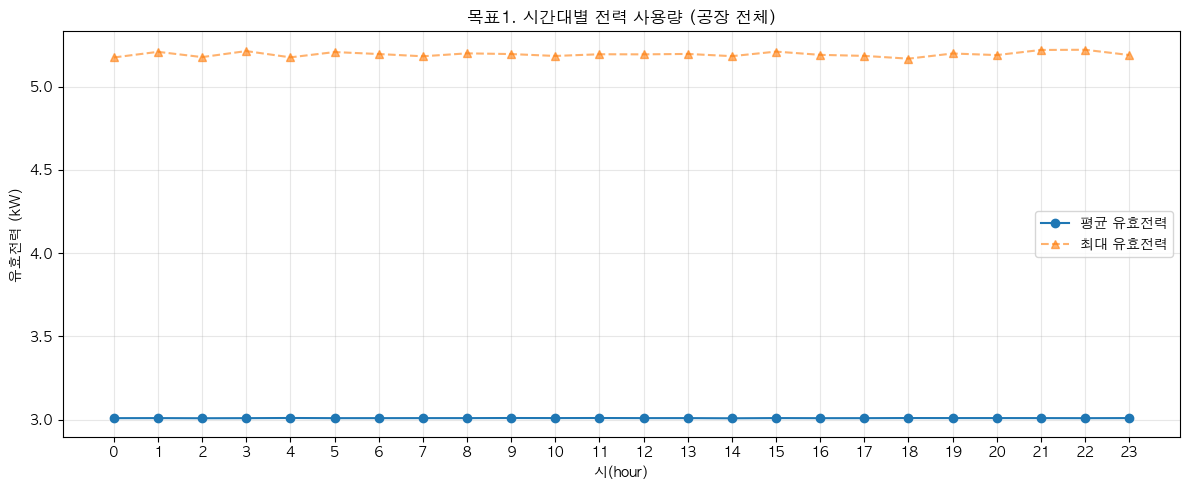

In [15]:
# 1-1. 시간대별 전체 공장 전력 프로파일 (24행만 반환됨 - 초경량)
hourly = q(f"""
    SELECT
        {HOUR_EXPR} AS hour,
        AVG(activePower) AS avg_power,
        MAX(activePower) AS max_power,
        COUNT(*)         AS n
    FROM `{TABLE}`
    GROUP BY hour
    ORDER BY hour;
""")
hourly["avg_power_kw"] = hourly["avg_power"] * POWER_SCALE
hourly["max_power_kw"] = hourly["max_power"] * POWER_SCALE
display(hourly[["hour", "avg_power_kw", "max_power_kw", "n"]])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly["hour"], hourly["avg_power_kw"], marker="o", label="평균 유효전력")
ax.plot(hourly["hour"], hourly["max_power_kw"], marker="^", ls="--", alpha=0.6, label="최대 유효전력")
ax.set_xlabel("시(hour)"); ax.set_ylabel("유효전력 (kW)")
ax.set_title("목표1. 시간대별 전력 사용량 (공장 전체)")
ax.set_xticks(range(0, 24)); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("./eda_out/01_hourly_power.png", dpi=120); plt.show()

# 목표 2. 설비 운영 데이터 분석
설비별 가동 통계 (평균전력, 가동시간 비율, 전압/전류 불평형 등)

In [16]:
# 2-1. 설비별 요약 통계 (13행만 반환)
by_module = q(f"""
    SELECT
        module,
        COUNT(*)              AS n_records,
        AVG(activePower)      AS avg_power,
        MAX(activePower)      AS max_power,
        STD(activePower)      AS std_power,
        AVG(powerFactorR)     AS avg_pf_r,
        AVG(powerFactorS)     AS avg_pf_s,
        AVG(powerFactorT)     AS avg_pf_t,
        AVG(reactivePowerLagging) AS avg_reactive,
        AVG(voltageR) AS avg_vr, AVG(voltageS) AS avg_vs, AVG(voltageT) AS avg_vt,
        AVG(currentR) AS avg_ir, AVG(currentS) AS avg_is, AVG(currentT) AS avg_it
    FROM `{TABLE}`
    GROUP BY module
    ORDER BY avg_power DESC;
""")

# 파생: 전압 불평형(%), 전류 불평형(%), 평균 역률, 변동계수(CV)
for c in ["avg_power", "max_power", "std_power", "avg_reactive"]:
    by_module[c] = by_module[c] * (POWER_SCALE if "power" in c or "reactive" in c else 1)

by_module["pf_avg"] = by_module[["avg_pf_r", "avg_pf_s", "avg_pf_t"]].mean(axis=1)
v_cols = ["avg_vr", "avg_vs", "avg_vt"]
i_cols = ["avg_ir", "avg_is", "avg_it"]
by_module["volt_unbalance_pct"] = (by_module[v_cols].max(axis=1) - by_module[v_cols].min(axis=1)) / by_module[v_cols].mean(axis=1) * 100
by_module["curr_unbalance_pct"] = (by_module[i_cols].max(axis=1) - by_module[i_cols].min(axis=1)) / by_module[i_cols].mean(axis=1) * 100
by_module["cv_power"] = by_module["std_power"] / by_module["avg_power"].replace(0, np.nan)  # 변동계수

display(by_module[["module", "n_records", "avg_power", "max_power", "cv_power",
                   "pf_avg", "avg_reactive", "volt_unbalance_pct", "curr_unbalance_pct"]])

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


  [쿼리 완료] 42.5초, 13행 반환


,module,n_records,avg_power,max_power,cv_power,pf_avg,avg_reactive,volt_unbalance_pct,curr_unbalance_pct
0,4(분쇄기(1)),2592001,3.011,5.207,0.238,92.500,0.602,0.002,0.045
1,1(PM-3),2592001,3.010,5.184,0.238,92.501,0.602,0.001,0.053
2,15(예비건조기),2592001,3.010,5.213,0.238,92.248,0.602,0.002,0.043
3,5(좌측분전반),2592001,3.010,5.176,0.238,92.499,0.602,0.002,0.063
4,18(우측분전반2),2592001,3.010,5.195,0.238,92.501,0.602,0.001,0.026
5,12(4호기),2592001,3.010,5.210,0.238,92.501,0.602,0.002,0.033
6,17(6호기),2592001,3.010,5.184,0.238,92.349,0.602,0.001,0.035
7,2(L-1전등),2592001,3.010,5.189,0.238,92.499,0.602,0.000,0.040
8,11(우측분전반1),2592001,3.010,5.221,0.238,92.504,0.602,0.001,0.032
9,16(호이스트),2592001,3.010,5.193,0.238,92.498,0.602,0.002,0.026


# 목표 3. 에너지 소비 패턴 분석
설비별 총 에너지 소비량(kWh) 및 비중 -> 어느 설비가 에너지를 많이 먹는지

,module,total_energy_kwh,energy_share_pct,avg_power
0,4(분쇄기(1)),"10,838.630",7.694,3.011
1,1(PM-3),"10,837.493",7.693,3.010
2,15(예비건조기),"10,837.475",7.693,3.010
3,5(좌측분전반),"10,836.940",7.693,3.010
4,18(우측분전반2),"10,836.172",7.693,3.010
5,12(4호기),"10,836.122",7.693,3.010
6,17(6호기),"10,835.797",7.692,3.010
7,2(L-1전등),"10,835.697",7.692,3.010
8,11(우측분전반1),"10,835.686",7.692,3.010
9,16(호이스트),"10,835.159",7.692,3.010


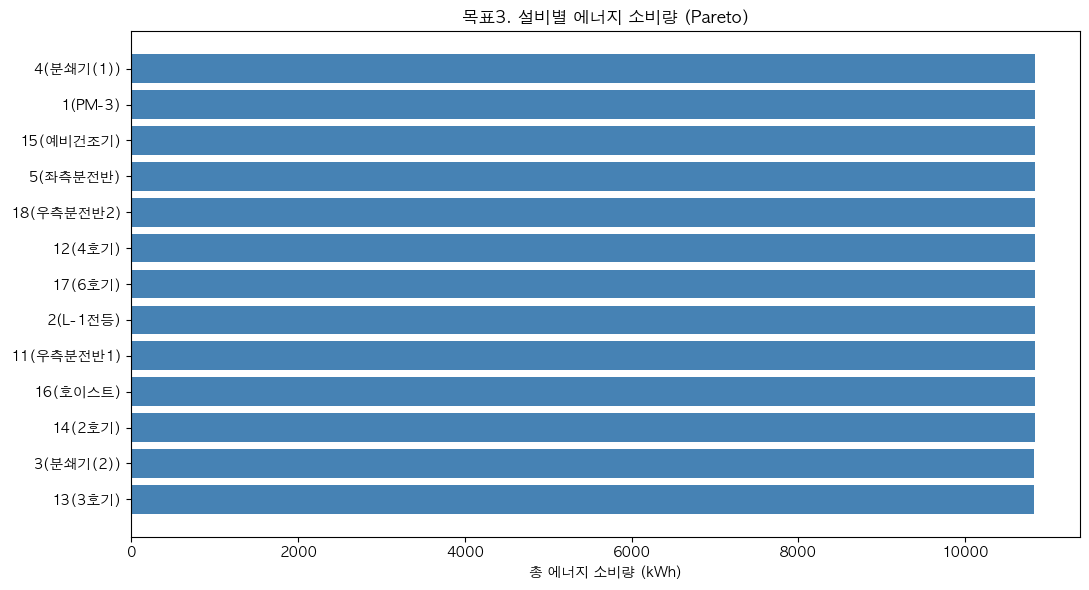

에너지 소비 파레토 (누적 비중):


,module,energy_share_pct,cum_share
0,4(분쇄기(1)),7.694,7.694
1,1(PM-3),7.693,15.388
2,15(예비건조기),7.693,23.081
3,5(좌측분전반),7.693,30.774
4,18(우측분전반2),7.693,38.467
5,12(4호기),7.693,46.159
6,17(6호기),7.692,53.852
7,2(L-1전등),7.692,61.544
8,11(우측분전반1),7.692,69.236
9,16(호이스트),7.692,76.928


In [17]:
# 3-1. 설비별 총 에너지 = 평균전력(kW) * 총 가동시간(h)
#     총 가동시간 = n_records * 샘플링주기(초) / 3600
by_module["total_hours"] = by_module["n_records"] * SAMPLING_SEC / 3600
by_module["total_energy_kwh"] = by_module["avg_power"] * by_module["total_hours"]
by_module["energy_share_pct"] = by_module["total_energy_kwh"] / by_module["total_energy_kwh"].sum() * 100

energy_rank = by_module.sort_values("total_energy_kwh", ascending=False)
display(energy_rank[["module", "total_energy_kwh", "energy_share_pct", "avg_power"]])

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(energy_rank["module"][::-1], energy_rank["total_energy_kwh"][::-1], color="steelblue")
ax.set_xlabel("총 에너지 소비량 (kWh)")
ax.set_title("목표3. 설비별 에너지 소비량 (Pareto)")
plt.tight_layout(); plt.savefig("./eda_out/03_energy_by_module.png", dpi=120); plt.show()

# 파레토: 상위 몇 개 설비가 전체 에너지의 80%를 차지하는지
energy_rank["cum_share"] = energy_rank["energy_share_pct"].cumsum()
print("에너지 소비 파레토 (누적 비중):")
display(energy_rank[["module", "energy_share_pct", "cum_share"]])

# 목표 4. 피크 시간대 분석
요일 x 시간대 평균 전력 히트맵 + 피크/비피크 구분

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


  [쿼리 완료] 19.8초, 168행 반환


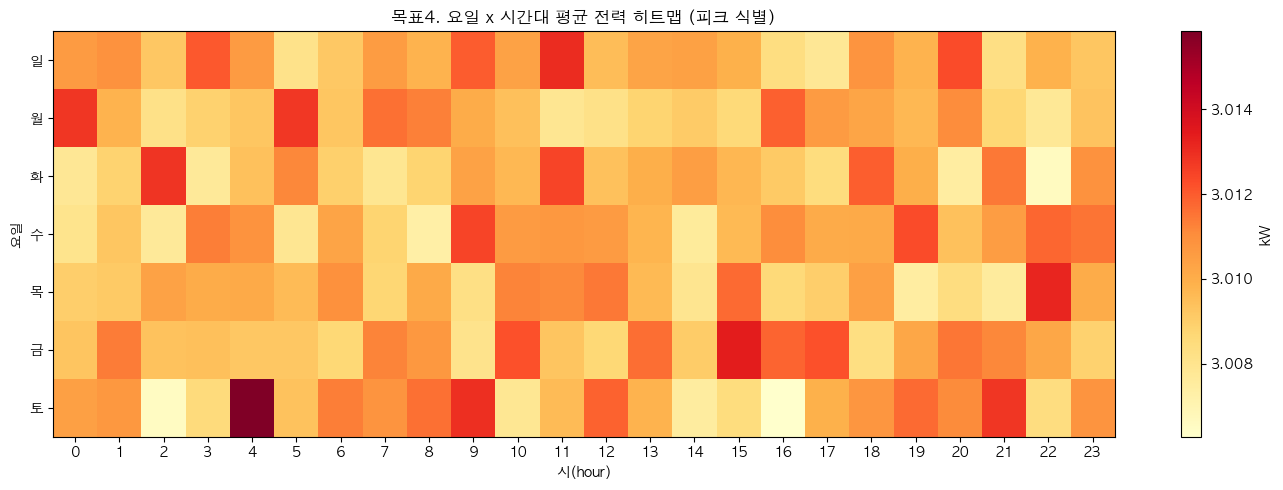

피크 시간대(상위 25% 전력): [4.0, 9.0, 10.0, 11.0, 18.0, 20.0]
피크 임계 전력: 3.0 kW


In [18]:
# 4-1. 요일 x 시간 히트맵 (7 x 24 = 168행만 반환)
dow_hour = q(f"""
    SELECT
        {DOW_EXPR} AS dow,  -- 1=일 ~ 7=토
        {HOUR_EXPR} AS hour,
        AVG(activePower) AS avg_power
    FROM `{TABLE}`
    GROUP BY dow, hour
    ORDER BY dow, hour;
""")
dow_hour["avg_power_kw"] = dow_hour["avg_power"] * POWER_SCALE

pivot = dow_hour.pivot(index="dow", columns="hour", values="avg_power_kw")
dow_labels = {1: "일", 2: "월", 3: "화", 4: "수", 5: "목", 6: "금", 7: "토"}
pivot.index = [dow_labels.get(d, d) for d in pivot.index]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("시(hour)"); ax.set_ylabel("요일")
ax.set_title("목표4. 요일 x 시간대 평균 전력 히트맵 (피크 식별)")
fig.colorbar(im, ax=ax, label="kW")
plt.tight_layout(); plt.savefig("./eda_out/04_peak_heatmap.png", dpi=120); plt.show()

# 4-2. 피크 시간대 자동 식별 (상위 25% 전력 시간대)
hourly_sorted = hourly.sort_values("avg_power_kw", ascending=False)
peak_threshold = hourly["avg_power_kw"].quantile(0.75)
peak_hours = sorted(hourly[hourly["avg_power_kw"] >= peak_threshold]["hour"].tolist())
print(f"피크 시간대(상위 25% 전력): {peak_hours}")
print(f"피크 임계 전력: {peak_threshold:,.1f} kW")

# 목표 5. 비효율 구간 분석
유효전력 변동성 + 저역률 + 전압/전류 불평형을 종합한 설비별 비효율 스코어

,module,inefficiency_score,cv_power,pf_avg,volt_unbalance_pct,curr_unbalance_pct
3,5(좌측분전반),0.618,0.238,92.499,0.002,0.063
2,15(예비건조기),0.558,0.238,92.248,0.002,0.043
11,3(분쇄기(2)),0.438,0.238,92.499,0.004,0.055
5,12(4호기),0.416,0.238,92.501,0.002,0.033
12,13(3호기),0.392,0.238,92.502,0.003,0.035
6,17(6호기),0.361,0.238,92.349,0.001,0.035
9,16(호이스트),0.356,0.238,92.498,0.002,0.026
7,2(L-1전등),0.329,0.238,92.499,0.000,0.040
0,4(분쇄기(1)),0.259,0.238,92.500,0.002,0.045
8,11(우측분전반1),0.242,0.238,92.504,0.001,0.032


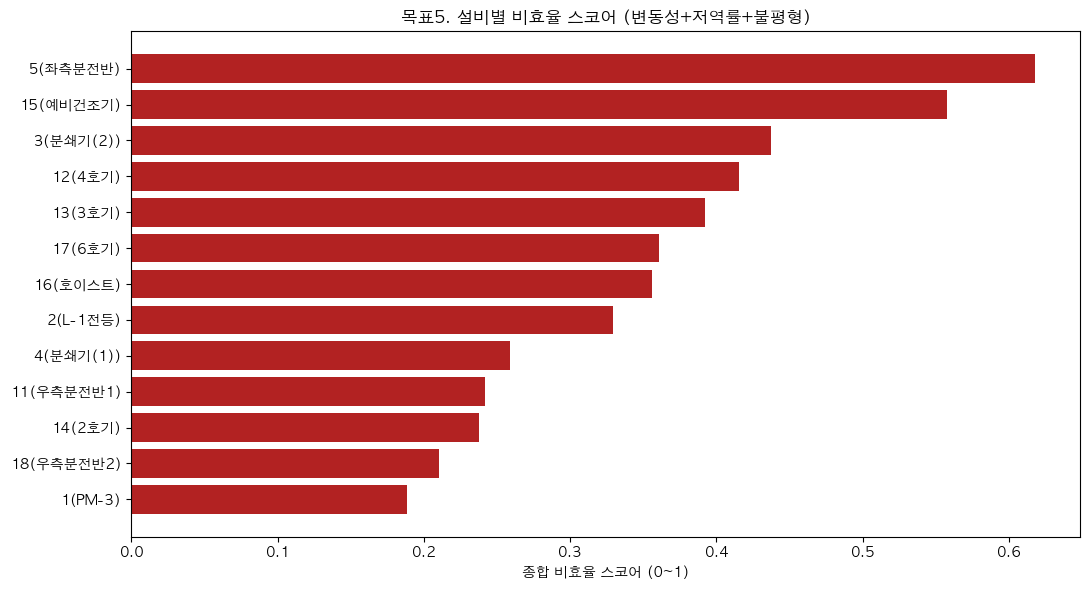

In [19]:
# 5-1. 설비별 비효율 지표 종합 (by_module 재활용, 추가 계산 없이 조합)
ineff = by_module[["module", "cv_power", "pf_avg", "volt_unbalance_pct",
                   "curr_unbalance_pct", "avg_reactive", "avg_power"]].copy()

# 각 지표를 0~1로 정규화해서 종합 비효율 스코어 산출
def _norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

ineff["score_volatility"]  = _norm(ineff["cv_power"])            # 변동성 클수록 비효율
ineff["score_low_pf"]      = _norm(1 - ineff["pf_avg"])          # 역률 낮을수록 비효율
ineff["score_volt_unbal"]  = _norm(ineff["volt_unbalance_pct"])  # 전압 불평형
ineff["score_curr_unbal"]  = _norm(ineff["curr_unbalance_pct"])  # 전류 불평형

ineff["inefficiency_score"] = (
    0.35 * ineff["score_volatility"] +
    0.30 * ineff["score_low_pf"] +
    0.15 * ineff["score_volt_unbal"] +
    0.20 * ineff["score_curr_unbal"]
)
ineff = ineff.sort_values("inefficiency_score", ascending=False)
display(ineff[["module", "inefficiency_score", "cv_power", "pf_avg",
               "volt_unbalance_pct", "curr_unbalance_pct"]])

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(ineff["module"][::-1], ineff["inefficiency_score"][::-1], color="firebrick")
ax.set_xlabel("종합 비효율 스코어 (0~1)")
ax.set_title("목표5. 설비별 비효율 스코어 (변동성+저역률+불평형)")
plt.tight_layout(); plt.savefig("./eda_out/05_inefficiency_score.png", dpi=120); plt.show()

# 목표 6. 공장 설비별 운영 특성 도출
설비를 운영 패턴으로 분류 (연속가동 / 주간가동 / 간헐배치)

In [20]:
# 6-1. 설비별 시간대 전력 프로파일 -> 운영 유형 자동 분류
# 각 설비의 시간대별 평균전력을 가져와서 야간/주간 비율로 패턴 판정
module_hourly = q(f"""
    SELECT
        module,
        {HOUR_EXPR} AS hour,
        AVG(activePower) AS avg_power
    FROM `{TABLE}`
    GROUP BY module, hour
    ORDER BY module, hour;
""")
module_hourly["avg_power_kw"] = module_hourly["avg_power"] * POWER_SCALE

def classify_operation(sub):
    day = sub[(sub["hour"] >= 8) & (sub["hour"] < 20)]["avg_power_kw"].mean()
    night = sub[(sub["hour"] < 8) | (sub["hour"] >= 20)]["avg_power_kw"].mean()
    peak = sub["avg_power_kw"].max()
    ratio = night / day if day > 0 else 0
    cv = sub["avg_power_kw"].std() / (sub["avg_power_kw"].mean() + 1e-9)
    if ratio > 0.7:
        op_type = "연속가동형"
    elif ratio < 0.2:
        op_type = "주간가동형"
    else:
        op_type = "부분가동형"
    if cv > 0.6:
        op_type += "(변동큼)"
    return pd.Series({"day_avg_kw": day, "night_avg_kw": night,
                      "night_day_ratio": ratio, "hourly_cv": cv, "op_type": op_type})

op_profile = module_hourly.groupby("module").apply(classify_operation).reset_index()
op_profile = op_profile.sort_values("day_avg_kw", ascending=False)
display(op_profile)

print("\n운영 유형별 설비 수:")
print(op_profile["op_type"].value_counts())

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_3268/1801284047.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


  [쿼리 완료] 61.4초, 312행 반환


,module,day_avg_kw,night_avg_kw,night_day_ratio,hourly_cv,op_type
8,18(우측분전반2),3.011,3.009,0.999,0.001,연속가동형
11,4(분쇄기(1)),3.010,3.011,1.000,0.001,연속가동형
5,15(예비건조기),3.010,3.010,1.000,0.001,연속가동형
0,1(PM-3),3.010,3.011,1.000,0.001,연속가동형
7,17(6호기),3.010,3.010,1.000,0.001,연속가동형
2,12(4호기),3.010,3.010,1.000,0.001,연속가동형
1,11(우측분전반1),3.010,3.010,1.000,0.001,연속가동형
4,14(2호기),3.010,3.010,1.000,0.001,연속가동형
10,3(분쇄기(2)),3.010,3.009,1.000,0.001,연속가동형
9,2(L-1전등),3.010,3.010,1.000,0.001,연속가동형



운영 유형별 설비 수:
op_type
연속가동형    13
Name: count, dtype: int64


In [21]:
# 종합 결과 저장 (분석 리포트용)
import os
os.makedirs("./eda_out", exist_ok=True)
by_module.to_csv("./eda_out/module_summary.csv", index=False, encoding="utf-8-sig")
ineff.to_csv("./eda_out/inefficiency_ranking.csv", index=False, encoding="utf-8-sig")
op_profile.to_csv("./eda_out/operation_profile.csv", index=False, encoding="utf-8-sig")
print("저장 완료: eda_out/ 폴더 (요약 CSV 3종 + 시각화 PNG 5종)")

저장 완료: eda_out/ 폴더 (요약 CSV 3종 + 시각화 PNG 5종)


## 오늘 분석 요약 (리포트 초안용)
- **목표1 시간대별**: 피크 시간대 = 위 peak_hours
- **목표2 설비운영**: 전압/전류 불평형, 역률 지표로 설비 상태 파악
- **목표3 에너지패턴**: 상위 N개 설비가 전체 에너지의 80% 차지 (파레토)
- **목표4 피크**: 요일x시간 히트맵으로 피크 구간 식별
- **목표5 비효율**: 변동성+저역률+불평형 종합 스코어로 우선순위화
- **목표6 운영특성**: 연속/주간/부분 가동형 분류

**유효전력 변동성(cv_power)이 높은 설비 = 오늘의 핵심 발견.**
변동이 큰 설비가 역률도 낮으면(score_low_pf 동반 상승) -> 단속운전/부하불안정 비효율 강력 시사.